In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import contingency
#from sklearn.preprocessing import StandardScaler
#from sklearn.metrics import r2_score
#from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

### Datenaufbereitung

Lade den Datensatz über die verfügbaren Apps im Google Play Store (googleplaystore.csv).

Überprüfe die Datenqualität anhand der Merkmale *Type* und *Price*. Gibt es Apps, die im Merkmal *Type* eine Merkmalsausprägung *Free* haben, aber einen Preis ungleich Null? Ebenso soll überprüft werden, ob es Apps mit *Price = 0* gibt, deren *Type* von *Free* abweicht. Einträge, die diese Kriterien verletzen, sollen aus dem Datensatz entfernt werden.

Überprüfe abschließend, ob Duplikate in den Einträgen existieren, und entferne diese gegebenenfalls.

In [4]:
apps = pd.read_csv('googleplaystore.csv', index_col=0)
#display(apps.head(5))
#display(apps.tail(5))
print('Größe des Datensatzes: {}'.format(apps.shape))

#Typ Free aber Preis ungleich 0
apps_Type_Free_Price=apps[
    (apps['Type']=='Free')&
    (apps['Price']!='0')
]
#display(apps_Type_Free_Price.head(5))
print('Größe des Datensatzes nach Suche nach Type "Free" und Preis ungleich "0": {}'.format(apps_Type_Free_Price.shape))

#Preis = 0 aber Typ ungleich Free
apps_Price_0_Type=apps[
    (apps['Price']=='0')&
    (apps['Type']!='Free')   
]
#display(apps_Price_0_Type.head(5))
print('Größe des Datensatzes nach Suche nach Preis "0" und Type ungleich "Free": {}'.format(apps_Price_0_Type.shape))

#Löschen der fehlerhaften Einträge

idx_bad_1 = apps_Type_Free_Price.index
idx_bad_2 = apps_Price_0_Type.index
idx_all_bad = idx_bad_1.union(idx_bad_2)

if not idx_all_bad.empty:
    apps_cleaned = apps.drop(idx_all_bad)
    print(f"{len(idx_all_bad)} fehlerhafte Einträge wurden entfernt.")
else:
    apps_cleaned = apps.copy()
    print("Keine fehlerhaften Einträge gefunden – es wurde nichts gelöscht.")

print("Größe nach dem Löschen:", apps_cleaned.shape)

#Duplikate
dup_count = apps_cleaned.duplicated().sum()
print(f'Anzahl der Duplikate im bereinigten Datensatz: {dup_count}')

if dup_count > 0:
    apps_cleaned_duplicate_free = apps_cleaned.drop_duplicates(keep='first')
    print(f'{dup_count} Duplikate wurden entfernt (1 Eintrag pro Duplikat bleibt erhalten).')
else:
    apps_cleaned_duplicate_free = apps_cleaned.copy()
    print('Keine Duplikate gefunden.')

print('Endgröße nach vollständiger Bereinigung:', apps_cleaned_duplicate_free.shape)


Größe des Datensatzes: (10841, 12)
Größe des Datensatzes nach Suche nach Type "Free" und Preis ungleich "0": (0, 12)
Größe des Datensatzes nach Suche nach Preis "0" und Type ungleich "Free": (1, 12)
1 fehlerhafte Einträge wurden entfernt.
Größe nach dem Löschen: (10840, 12)
Anzahl der Duplikate im bereinigten Datensatz: 492
492 Duplikate wurden entfernt (1 Eintrag pro Duplikat bleibt erhalten).
Endgröße nach vollständiger Bereinigung: (10348, 12)


### Datenuntersuchung

Gib folgende Kennzahlen und Eigenschaften des Datensatzes an:  
- Wie viele Einträge existieren?  
- Auf welchen Skalen sind die unterschiedlichen Merkmale definiert?  
- Welchen Modus haben die Merkmale *Category*, *Content Rating* und *Genres*?  

Stelle zusätzlich folgende Grafiken dar:  
- für *Category*: absolute Häufigkeit  
- für *Content Rating*: relative Häufigkeit  
- für *Genres*: absolute Häufigkeit der Top 20, sortiert nach Anzahl  

Wie viele Merkmalsausprägungen existieren für *Genres*?

Verwendeter DataFrame: ['apps_cleaned_duplicate_free', 'apps_cleaned', 'df_clean', 'df', 'apps']

1) Anzahl Einträge: (10348, 12) (Zeilen, Spalten)

2) Geschätzte Skalentypen (Auswahl, erste 20 Spalten):
 - Category: kategorial (nominal) / string
 - Rating: metrisch (Interval/Ratio)
 - Reviews: kategorial (nominal) / string
 - Size: kategorial (nominal) / string
 - Installs: kategorial (nominal) / string
 - Type: kategorial (nominal/ordinal) ~ 3 Ausprägungen
 - Price: kategorial (nominal) / string
 - Content Rating: kategorial (nominal/ordinal) ~ 6 Ausprägungen
 - Genres: kategorial (nominal) / string
 - Last Updated: kategorial (nominal) / string
 - Current Ver: kategorial (nominal) / string
 - Android Ver: kategorial (nominal) / string

3) Modi:
 - Category: FAMILY
 - Content Rating: Everyone
 - Genre (häufigster Eintrag): Tools (insgesamt 55 verschiedene Genres)


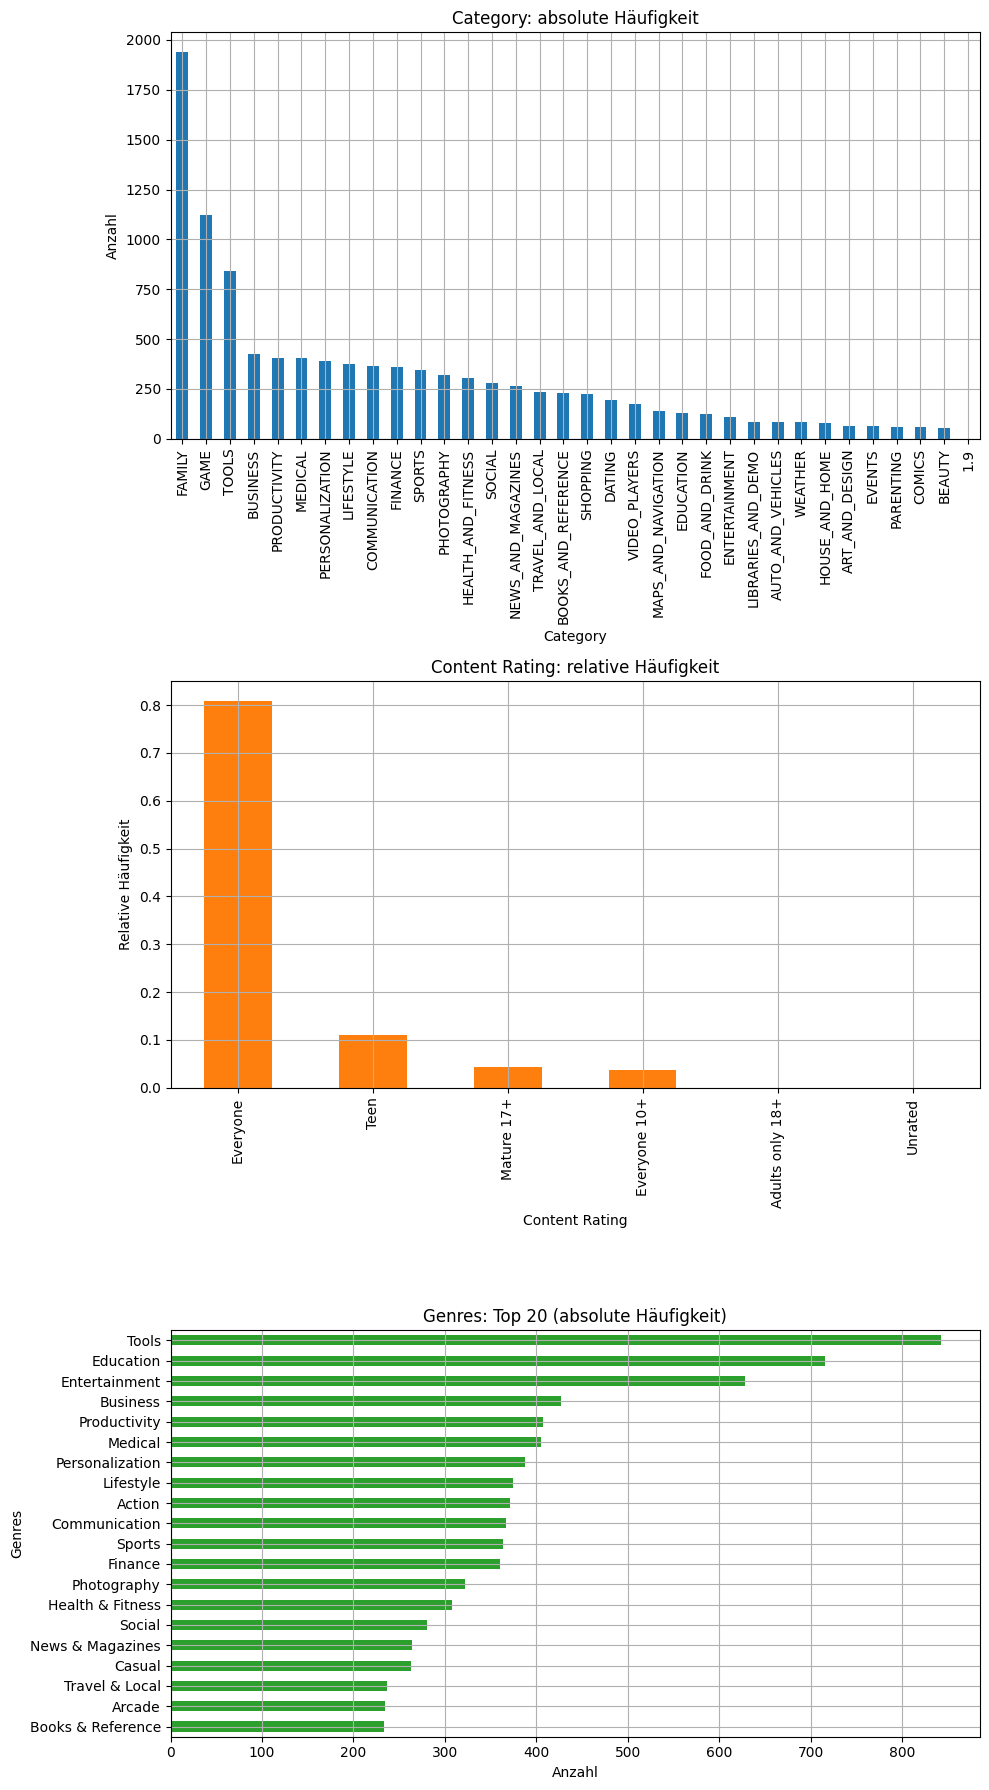

,metric,value
0,num_entries,10348
1,num_columns,12
2,mode_category,FAMILY
3,mode_content_rating,Everyone
4,mode_genre,Tools
5,num_unique_genres,55


In [6]:
# Datenuntersuchung: Kennzahlen, Modi und Plots
# wähle bereinigten DF falls vorhanden, sonst greifen wir auf apps zurück
df = globals().get('apps_cleaned_duplicate_free', None)
if df is None:
    df = globals().get('apps_cleaned', None)
if df is None:
    df = globals().get('df_clean', None)
if df is None:
    df = globals().get('df', None)
if df is None:
    df = globals().get('apps', None)

print('Verwendeter DataFrame:', [name for name in ['apps_cleaned_duplicate_free','apps_cleaned','df_clean','df','apps'] if name in globals()])
print('\n1) Anzahl Einträge: {} (Zeilen, Spalten)'.format(df.shape))

# 2) Skalenabschätzung (heuristisch)
def infer_scale(col, series):
    if pd.api.types.is_numeric_dtype(series):
        return 'metrisch (Interval/Ratio)'
    # geringe Anzahl verschiedener Werte -> nominal/ordinal
    nunique = series.dropna().unique().shape[0]
    if nunique <= 10:
        return 'kategorial (nominal/ordinal) ~ {} Ausprägungen'.format(nunique)
    return 'kategorial (nominal) / string'

scales = {col: infer_scale(col, df[col]) for col in df.columns}
print('\n2) Geschätzte Skalentypen (Auswahl, erste 20 Spalten):')
for k,v in list(scales.items())[:20]:
    print(f" - {k}: {v}")

# 3) Modi für Category, Content Rating und Genres
def safe_mode(series):
    return series.dropna().mode().iloc[0] if not series.dropna().empty else None

mode_category = safe_mode(df['Category']) if 'Category' in df.columns else None
mode_content = safe_mode(df['Content Rating']) if 'Content Rating' in df.columns else None

# Genres: einzelne Genres extrahieren (Trennzeichen ; oder ,)
if 'Genres' in df.columns:
    genres_series = df['Genres'].dropna().astype(str)
    # split by ';' or ',' and explode
    genres_exp = genres_series.str.split('[;,]').explode().str.strip()
    genres_counts = genres_exp.value_counts()
    mode_genre = genres_counts.idxmax() if not genres_counts.empty else None
    num_unique_genres = genres_counts.shape[0]
else:
    genres_counts = pd.Series([], dtype=int)
    mode_genre = None
    num_unique_genres = 0

print('\n3) Modi:')
print(f" - Category: {mode_category}")
print(f" - Content Rating: {mode_content}")
print(f" - Genre (häufigster Eintrag): {mode_genre} (insgesamt {num_unique_genres} verschiedene Genres)")


plt.rcParams.update({'figure.max_open_warning': 0})

fig, axs = plt.subplots(3,1,figsize=(10,18))

# Category: absolute Häufigkeit
if 'Category' in df.columns:
    cat_counts = df['Category'].value_counts().sort_values(ascending=False)
    cat_counts.plot.bar(ax=axs[0], color='tab:blue')
    axs[0].set_title('Category: absolute Häufigkeit')
    axs[0].set_ylabel('Anzahl')
    axs[0].grid(True)
else:
    axs[0].text(0.5,0.5,'Spalte Category nicht gefunden', ha='center')
    axs[0].grid(False)

# Content Rating: relative Häufigkeit
if 'Content Rating' in df.columns:
    cr = df['Content Rating'].value_counts(normalize=True).sort_values(ascending=False)
    cr.plot.bar(ax=axs[1], color='tab:orange')
    axs[1].set_title('Content Rating: relative Häufigkeit')
    axs[1].set_ylabel('Relative Häufigkeit')
    axs[1].grid(True)
else:
    axs[1].text(0.5,0.5,'Spalte Content Rating nicht gefunden', ha='center')
    axs[1].grid(False)

# Genres: Top 20 absolute Häufigkeit
if not genres_counts.empty:
    genres_counts.head(20).sort_values(ascending=True).plot.barh(ax=axs[2], color='tab:green')
    axs[2].set_title('Genres: Top 20 (absolute Häufigkeit)')
    axs[2].set_xlabel('Anzahl')
    axs[2].grid(True)
else:
    axs[2].text(0.5,0.5,'Spalte Genres nicht gefunden oder keine Werte', ha='center')
    axs[2].grid(False)

plt.tight_layout()
plt.show()

# Ausgabe der wichtigsten Kennzahlen als DataFrame
summary = pd.DataFrame([
    {'metric':'num_entries','value': df.shape[0]},
    {'metric':'num_columns','value': df.shape[1]},
    {'metric':'mode_category','value': str(mode_category)},
    {'metric':'mode_content_rating','value': str(mode_content)},
    {'metric':'mode_genre','value': str(mode_genre)},
    {'metric':'num_unique_genres','value': int(num_unique_genres)}
])
display(summary)

### Zusammenhang Qualitative Merkmale

Erstelle die Kreuztabelle für die Merkmale *Content Rating* und *Type*. Berechne damit die folgenden bedingten Häufigkeiten:

- P(Paid | Everyone)  
- P(Mature | Free)  
- Die Wahrscheinlichkeit, dass eine App mit Content Rating *Teen* kostenlos ist.  

Bewerte anschließend die statistische Abhängigkeit der beiden Merkmale basierend auf dem korrigierten Kontingenzkoeffizienten.  


In [23]:
ct=pd.crosstab(df['Content Rating'], df['Type'],margins=True)
display(ct)

Paid = 662
EveryoneAll= 8373

Mature = 428
FreeAll=9582
print('P(Type = Paid | Content Rating = Everyone) : {0:.4f}'.format(Paid/EveryoneAll))
print('P(Content Rating = Mature | Type = Free) : {0:.4f}'.format(Mature/FreeAll))

Type,Free,Paid,All
Content Rating,,,
Adults only 18+,3,0,3
Everyone,7711,662,8373
Everyone 10+,344,32,376
Mature 17+,428,19,447
Teen,1094,52,1146
Unrated,2,0,2
All,9582,765,10347


P(Type = Paid | Content Rating = Everyone) : 0.0791
P(Content Rating = Mature | Type = Free) : 0.0447


### Quantitative Merkmale

Lade den Datensatz *Advertising.csv* ein.

Der Datensatz hat 4 Merkmale und 200 Beobachtungen. Die Merkmale sind:
- *TV* - Werbebudget in Geldeinheiten [GE] für Spots im TV
- *radio* - Werbebudget in GE für Ansagen im Radio
- *newspaper* - Werbebudget in GE für Announcen in Zeitungen
- *sales* - Anzahl verkaufter Produkte [in Tsd.].

Fragestellungen:  
- Stelle für das Merkmal *TV* einen kumulativen Häufigkeitsplot dar. Welches minimale Budget haben die 30% Kampagnen mit dem höchsten TV-Budget?  
- Stelle für das Merkmal *newspaper* einen Boxplot dar. Wie viele Ausreißer existieren?

Gib zusätzlich für alle Merkmale jeweils den Median, den Interquartilsabstand, den arithmetischen Mittelwert und die Standardabweichung an.  

### Zusammenhänge quantitativer Merkmale

Stelle einen pairplot für den Datensatz dar und bestimme die Korrelationsmatrix.

Berechne die Lineare Regression für *sales* basierend auf *TV* und beantworte folgende Fragen:
- Wie lautet das Modell der Linearen Regression?
- Sind die Koeffizienten signifikant?
- Welche Aussagen über die Residuen lassen ableiten?
- Welche Aussage lässt sich aus dem Bestimmtsmaß ableiten?  
- Würdest du das Modell in der Praxis benutzen?

Stelle zusätzlich Grafiken dar, um das Ergebnis und die Qualität der Linearen Regression zu visualisieren.


Bestimme danach die multiple lineare Regression für *sales* bei Benutzung der aller Merkmale.

Beantworte folgende Fragen:

- Ist die multiple lineare Regression *besser* als die einfache lineare Regression?
- Haben alle 3 Merkmale einen Einfluss auf das Ergebnis?

Stelle auch für diesen Fall Grafiken dar, um das Ergebnis und die Qualität zu visualisieren. 